In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from astropy.io import fits
import pandas as pd

In [3]:
cam_12574 = fits.open("./Data/12574/2026_03_23__17_14_12_cube.fits")
cam_12606 = fits.open("./Data/12606/2026_03_23__17_14_12_cube.fits")
cam_13251 = fits.open("./Data/13251/2026_03_23__17_14_12_cube.fits")
cam_13703 = fits.open("./Data/13703/2026_03_23__17_14_12_cube.fits")


In [4]:
df_12574 = cam_12574[0].data
df_12606 = cam_12606[0].data
df_13251 = cam_13251[0].data
df_13703 = cam_13703[0].data


## 12574

LED is positioned within a box of length L=50, W=100, centered at (360, 450)

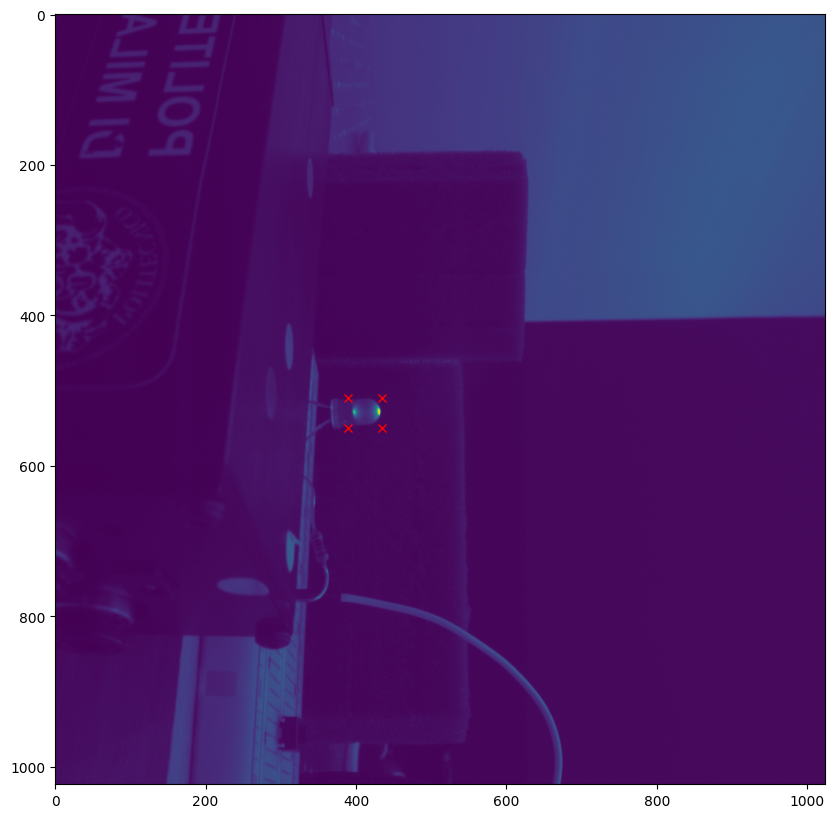

In [ ]:
plt.figure(figsize=(15, 10))
plt.imshow(df_13251[7])
plt.plot(390, 510, marker="x", color="red")
plt.plot(435, 510, marker="x", color="red")
plt.plot(390, 550, marker="x", color="red")
plt.plot(435, 550, marker="x", color="red")

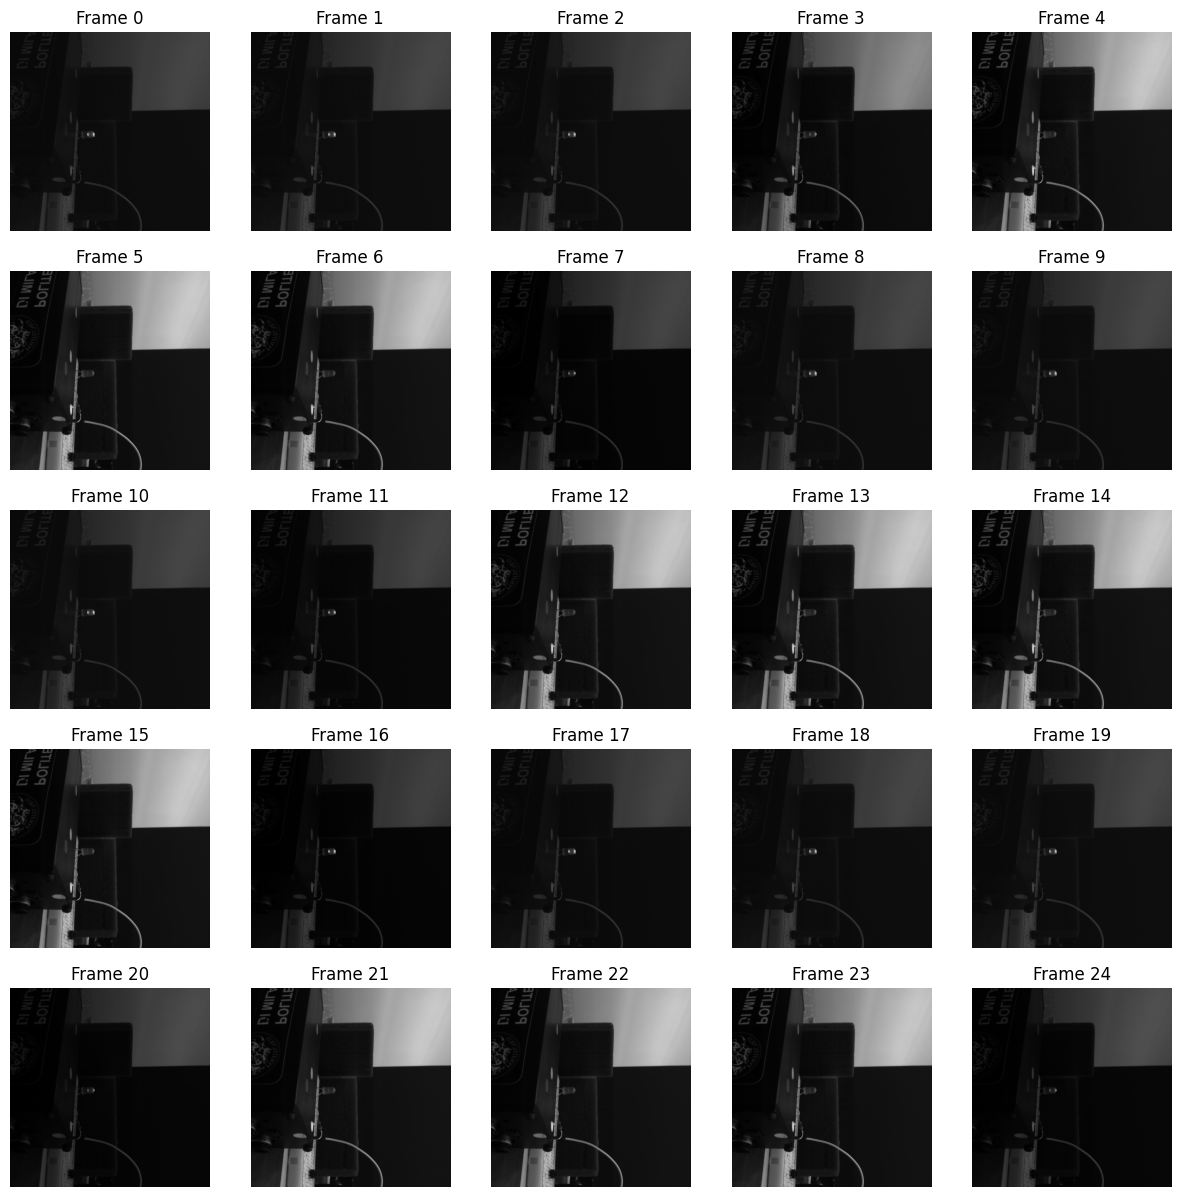

In [6]:
fig, ax = plt.subplots(5, 5, figsize=(15, 15))

df = df_13703

for row in range(5):
    for col in range(5):
        idx = row * 5 + col
        if idx < df.shape[0]:  # check if index is within bounds
            ax[row, col].imshow(df[idx], cmap='gray')
            ax[row, col].set_title(f'Frame {idx}')
            ax[row, col].axis('off')




# With LED ON

In [32]:
# Use the first frame and numpy slicing for the box integration
arr = df_12574[0]  # select the first 2D frame
# box coordinates (xmin..xmax, ymin..ymax)
xmin, xmax = 320, 420
ymin, ymax = 420, 470
# slice: array indexing is arr[row, col] -> arr[y, x]
sub = arr[ymin:ymax+1, xmin:xmax+1]
mean_val_ON = np.mean(sub)
sum_val_ON = np.sum(sub)
print('mean_ON =', mean_val_ON)
print('sum ON =', sum_val_ON)

mean_ON = 2272.384779654436
sum ON = 11705054


# WITH LED OFF

In [34]:
# Use the first frame and numpy slicing for the box integration
arr = df_12574[4]  # select the first 2D frame
# box coordinates (xmin..xmax, ymin..ymax)
xmin, xmax = 320, 420
ymin, ymax = 420, 470
# slice: array indexing is arr[row, col] -> arr[y, x]
sub = arr[ymin:ymax+1, xmin:xmax+1]
mean_val_OFF = np.mean(sub)
sum_val_OFF = np.sum(sub)
print('mean OFF =', mean_val_OFF)
print('sum OFF =', sum_val_OFF)

mean OFF = 1235.9400116482236
sum OFF = 6366327


In [ ]:
avg_led_on = []
sum_led_on = []

avg_led_off = []
sum_led_off = []


ON_FRAMES = [0, 1, 6, 7, 8, 9, 14, 15, 16, 17, 18, 23, 24, 25, 26, 31, 32, 33, 34, 35, 40, 41, 42, 43]
OFF_FRAMES = [2, 3, 4, 5, 10, 11, 12, 13, 19, 20, 21, 22, 27, 28, 29, 30, 36, 37, 38, 39, 45, 46, 47, 48, 53]




for i in ON_FRAMES:
    arr = df_12574[i]  # select the first 2D frame
    # box coordinates (xmin..xmax, ymin..ymax)
    xmin, xmax = 320, 420
    ymin, ymax = 420, 470
    # slice: array indexing is arr[row, col] -> arr[y, x]
    sub = arr[ymin:ymax+1, xmin:xmax+1]
    avg_led_on.append(np.mean(sub))
    sum_led_on.append(np.sum(sub))

for i in OFF_FRAMES:
    arr = df_12574[i]  # select the first 2D frame
    # box coordinates (xmin..xmax, ymin..ymax)
    xmin, xmax = 320, 420
    ymin, ymax = 420, 470
    # slice: array indexing is arr[row, col] -> arr[y, x]
    sub = arr[ymin:ymax+1, xmin:xmax+1]
    avg_led_off.append(np.mean(sub))
    sum_led_off.append(np.sum(sub))


# avg_led_off_int = np.mean(mean_values)

print(f"Average LED ON = {np.mean(avg_led_on)}")
print(f"Average LED OFF = {np.mean(avg_led_off)}")

print(f"Sum LED ON = {np.mean(sum_led_on)}")
print(f"Sum LED OFF = {np.mean(sum_led_off)}")

print(f"Minimum LED ON = {np.min(avg_led_on)}")
print(f"Minimum LED OFF = {np.min(avg_led_off)}")

print(f"Maximum LED ON = {np.max(avg_led_on)}")
print(f"Maximum LED OFF = {np.max(avg_led_off)}")

print(f"Shape of ON Frames {len(ON_FRAMES)}")

Average LED ON = 2193.10047401799
Average LED OFF = 1266.1227878081925
Sum LED ON = 11296660.541666666
Sum LED OFF = 6521798.48
Minimum LED ON = 1662.8928363424577
Minimum LED OFF = 1233.9627256843332
Maximum LED ON = 2280.622791690934
Maximum LED OFF = 1510.89594253543
Shape of ON Frames 24


In [54]:
num_of_images_led_on = 0
num_of_imaged_led_off = 0

for i in range(df_12574.shape[0]):
    arr = df_12574[i]  # select the first 2D frame
    # box coordinates (xmin..xmax, ymin..ymax)
    xmin, xmax = 320, 420
    ymin, ymax = 420, 470
    # slice: array indexing is arr[row, col] -> arr[y, x]
    sub = arr[ymin:ymax+1, xmin:xmax+1]
    avg = np.mean(sub)
    sum = np.sum(sub)


    if (avg > np.min(avg_led_on)):
        num_of_images_led_on += 1
    else:
        num_of_imaged_led_off += 1
print(f"Number of images with LED ON = {num_of_images_led_on}")
print(f"Number of images with LED OFF = {num_of_imaged_led_off}")
print(f"Total number of images = {num_of_images_led_on + num_of_imaged_led_off}")

Number of images with LED ON = 259
Number of images with LED OFF = 241
Total number of images = 500


# 12606

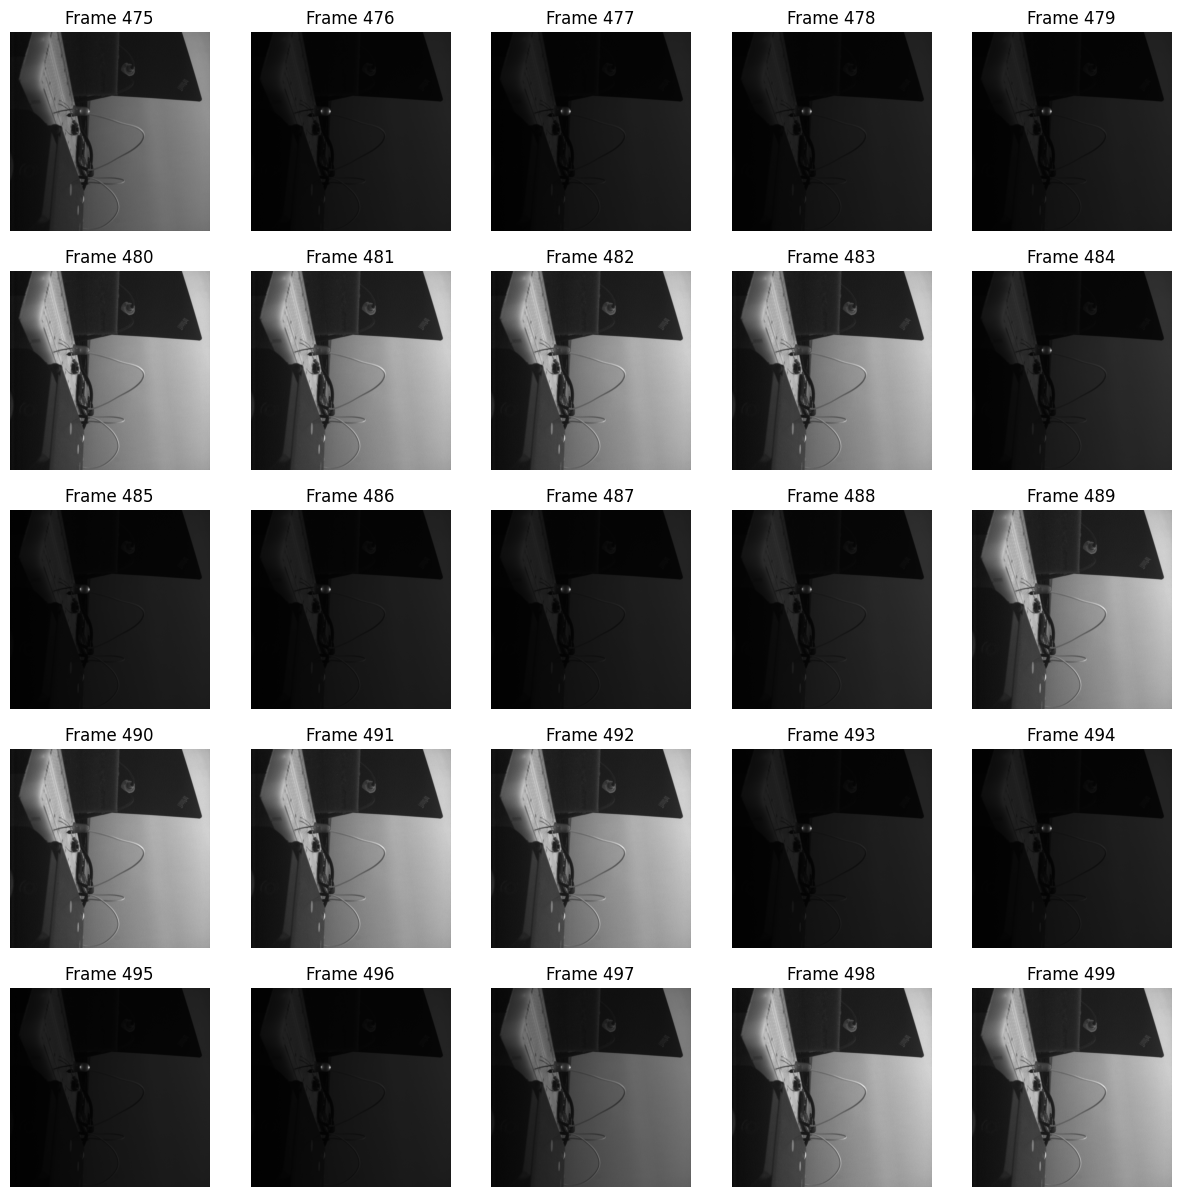

In [12]:
n_frames = df_12606.shape[0]
start = max(0, n_frames - 25)
indices = list(range(start, n_frames))

fig, ax = plt.subplots(5, 5, figsize=(15, 15))

for i in range(25):
    r, c = divmod(i, 5)
    if i < len(indices):
        idx = indices[i]
        ax[r, c].imshow(df_12606[idx], cmap='gray')
        ax[r, c].set_title(f'Frame {idx}')
    ax[r, c].axis('off')

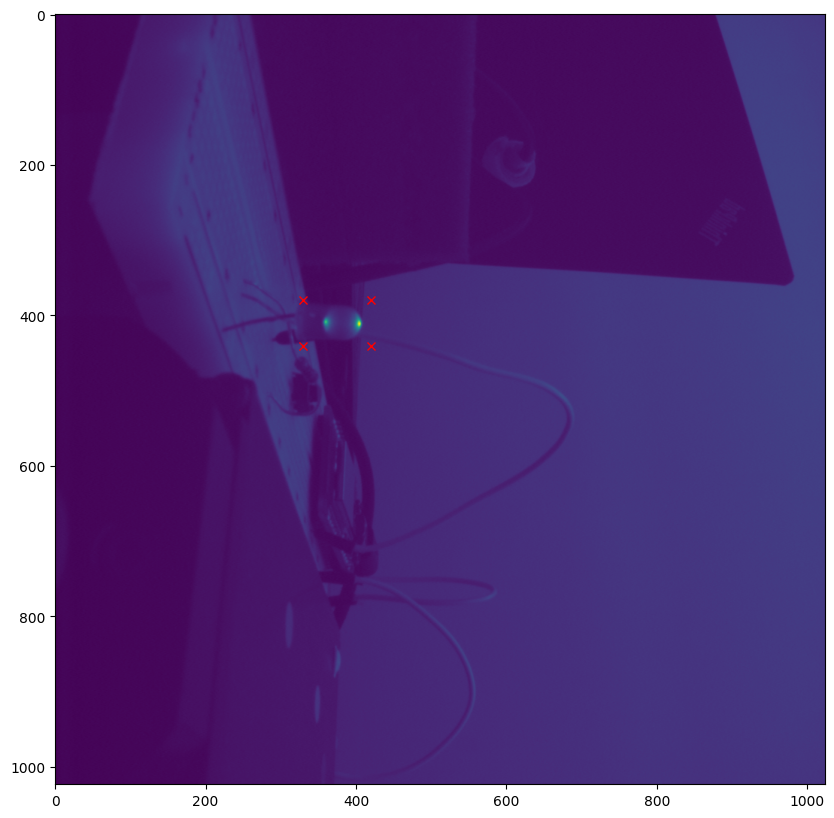

In [65]:
plt.figure(figsize=(15, 10))
plt.imshow(df_12606[12])
plt.plot(330, 380, marker="x", color="red")
plt.plot(420, 380, marker="x", color="red")
plt.plot(330, 440, marker="x", color="red")
plt.plot(420, 440, marker="x", color="red")


In [4]:
avg_led_on = []
sum_led_on = []

avg_led_off = []
sum_led_off = []


ON_FRAMES = [12, 13, 14, 15, 16, 21, 22, 23, 24, 29, 30, 31, 32, 33, 38, 39, 40, 41, 42, 47, 48, 49, 50, 55]
OFF_FRAMES = [10, 11, 17, 18, 19, 20, 25, 26, 27, 28, 34, 35, 36, 37, 43, 44, 45, 46, 51, 52, 53, 54, 60, 61]




for i in ON_FRAMES:
    arr = df_12606[i]  # select the first 2D frame
    # box coordinates (xmin..xmax, ymin..ymax)
    xmin, xmax = 330, 420
    ymin, ymax = 380, 440
    # slice: array indexing is arr[row, col] -> arr[y, x]
    sub = arr[ymin:ymax+1, xmin:xmax+1]
    avg_led_on.append(np.mean(sub))
    sum_led_on.append(np.sum(sub))

for i in OFF_FRAMES:
    arr = df_12606[i]  # select the first 2D frame
    # box coordinates (xmin..xmax, ymin..ymax)
    xmin, xmax = 330, 420
    ymin, ymax = 380, 440
    # slice: array indexing is arr[row, col] -> arr[y, x]
    sub = arr[ymin:ymax+1, xmin:xmax+1]
    avg_led_off.append(np.mean(sub))
    sum_led_off.append(np.sum(sub))


# avg_led_off_int = np.mean(mean_values)

print(f"Average LED ON = {np.mean(avg_led_on)}")
print(f"Average LED OFF = {np.mean(avg_led_off)}")

print(f"Sum LED ON = {np.mean(sum_led_on)}")
print(f"Sum LED OFF = {np.mean(sum_led_off)}")

print(f"Minimum LED ON = {np.min(avg_led_on)}")
print(f"Minimum LED OFF = {np.min(avg_led_off)}")

print(f"Maximum LED ON = {np.max(avg_led_on)}")
print(f"Maximum LED OFF = {np.max(avg_led_off)}")

print(f"Shape of ON Frames {len(ON_FRAMES)}")

Average LED ON = 1234.2226325586983
Average LED OFF = 829.2374647210712
Sum LED ON = 6851169.833333333
Sum LED OFF = 4603097.166666667
Minimum LED ON = 1002.0468384074942
Minimum LED OFF = 817.360655737705
Maximum LED ON = 1282.7265357593226
Maximum LED OFF = 948.7241938389479
Shape of ON Frames 24


In [5]:
num_of_images_led_on = 0
num_of_imaged_led_off = 0

for i in range(10, df_12606.shape[0]):
    arr = df_12606[i]  # select the first 2D frame
    # box coordinates (xmin..xmax, ymin..ymax)
    xmin, xmax = 330, 420
    ymin, ymax = 380, 440
    # slice: array indexing is arr[row, col] -> arr[y, x]
    sub = arr[ymin:ymax+1, xmin:xmax+1]
    avg = np.mean(sub)
    sum = np.sum(sub)


    if (avg > np.min(avg_led_on)):
        num_of_images_led_on += 1
    else:
        num_of_imaged_led_off += 1
print(f"Number of images with LED ON = {num_of_images_led_on}")
print(f"Number of images with LED OFF = {num_of_imaged_led_off}")
print(f"Total number of images = {num_of_images_led_on + num_of_imaged_led_off}")

Number of images with LED ON = 254
Number of images with LED OFF = 236
Total number of images = 490


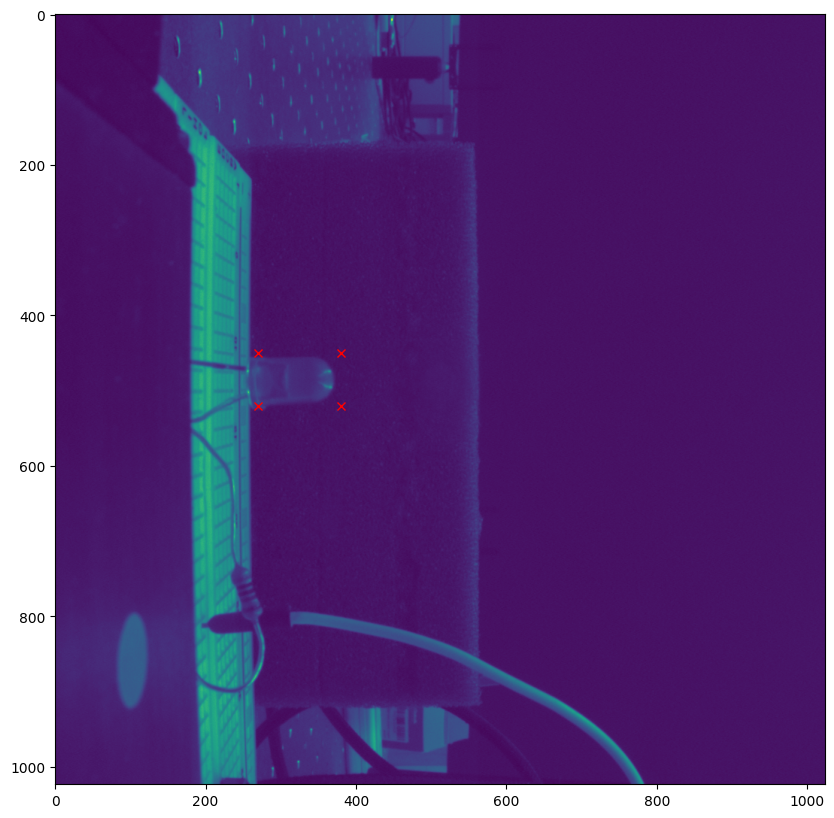

In [24]:
plt.figure(figsize=(15, 10))
plt.imshow(df_13703[5])
plt.plot(270, 450, marker="x", color="red")
plt.plot(270, 520, marker="x", color="red")
plt.plot(380, 450, marker="x", color="red")
plt.plot(380, 520, marker="x", color="red")